# RFM Analysis - Online Retail Dataset

## What is RFM Analysis?

**RFM** stands for **Recency**, **Frequency**, and **Monetary value**. It is a customer segmentation technique that scores customers based on three behavioral dimensions:

1. **Recency** – How recently did the customer make a purchase? (e.g., days since last order)
2. **Frequency** – How often does the customer purchase? (e.g., number of orders)
3. **Monetary** – How much does the customer spend? (e.g., total revenue)

Each dimension is typically scored (e.g., 1–5), with higher scores indicating better behavior. Customers are then grouped into segments based on these scores.

## How Does RFM Add Value to Businesses?

RFM helps businesses:

- **Prioritize customers** – Focus marketing and retention efforts on high-value or at-risk segments
- **Personalize offers** – Tailor promotions, discounts, or messages by segment (e.g., win-back for inactive, loyalty rewards for frequent)
- **Improve ROI** – Spend less on unlikely responders and more on segments with higher conversion potential
- **Predict churn** – Low Recency + low Frequency often indicates churning or lost customers
- **Identify advocates** – High R, F, and M customers are ideal for referral programs and testimonials

## What Can We Learn from RFM on an E-Commerce Dataset?

On an e-commerce transaction dataset like Online Retail:

- **Recency** – Who bought recently vs. who hasn’t purchased in a while (e.g., 90+ days)
- **Frequency** – One-time buyers vs. repeat customers; purchase frequency by segment
- **Monetary** – Revenue contribution by segment; how much top customers spend vs. others
- **Segment profiles** – "Champions" (high R, F, M), "At Risk" (low R, high F, M), "Lost" (low R, F, M), etc.
- **Actionability** – Which segments to target for reactivation, loyalty, or acquisition campaigns

---

## Setup and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load and clean data (same logic as retail_data_analysis.ipynb)
df = pd.read_excel('Online Retail.xlsx')

df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
df_clean = df_clean.dropna(subset=['Description', 'CustomerID'])
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Loaded {len(df_clean):,} rows for RFM analysis")

Loaded 392,692 rows for RFM analysis


## Compute RFM Metrics

In [4]:
# Reference date: day after the last transaction in the dataset
ref_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date for Recency: {ref_date.date()}")

# Aggregate at customer level (one row per InvoiceNo per customer, then aggregate)
orders = df_clean.groupby(['CustomerID', 'InvoiceNo']).agg(
    Revenue=('Revenue', 'sum'),
    InvoiceDate=('InvoiceDate', 'max')
).reset_index()

# RFM metrics per customer
rfm = orders.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (ref_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

print(f"\nRFM computed for {len(rfm):,} customers")
rfm.head(10)

Reference date for Recency: 2011-12-10

RFM computed for 4,338 customers


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


In [5]:
# Score each metric 1-5 (5 = best)
# Recency: lower is better, so we use quintiles and invert (q5=1, q1=5)
# Frequency and Monetary: higher is better (q5=5, q1=1)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop')
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')

# Convert to numeric for aggregation
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,326,1,77183.60,1,1,5,115
1,12347.0,2,7,4310.00,5,5,5,555
2,12348.0,75,4,1797.24,2,4,4,244
3,12349.0,19,1,1757.55,4,1,4,414
4,12350.0,310,1,334.40,1,1,2,112
5,12352.0,36,8,2506.04,3,5,5,355
6,12353.0,204,1,89.00,1,1,1,111
7,12354.0,232,1,1079.40,1,1,4,114
8,12355.0,214,1,459.40,1,1,2,112
9,12356.0,23,3,2811.43,4,3,5,435


## RFM Segmentation

In [6]:
def assign_rfm_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 4 and f >= 2 and m >= 2:
        return 'Loyal Customers'
    elif r >= 4 and f <= 1 and m <= 1:
        return 'Promising'
    elif r >= 3 and f <= 2 and m <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 2 and m >= 2:
        return 'Cant Lose'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Hibernating'
    elif r <= 1 and f <= 1 and m <= 2:
        return 'Lost'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(assign_rfm_segment, axis=1)

print("Segment distribution:")
print(rfm['Segment'].value_counts().sort_values(ascending=False))

Segment distribution:
Segment
Others             1085
Champions           957
Loyal Customers     578
At Risk             453
Cant Lose           418
New Customers       351
Lost                310
Hibernating         111
Promising            75
Name: count, dtype: int64


## Segment Summary

In [7]:
segment_summary = rfm.groupby('Segment').agg(
    Count=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).round(2)
segment_summary['Pct_Customers'] = (100 * segment_summary['Count'] / len(rfm)).round(1)
segment_summary['Pct_Revenue'] = (100 * segment_summary['Total_Revenue'] / rfm['Monetary'].sum()).round(1)
segment_summary = segment_summary.sort_values('Total_Revenue', ascending=False)
segment_summary

,Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Pct_Customers,Pct_Revenue
Segment,,,,,,,
Champions,957,12.82,11.12,6051.87,5791640.74,22.1,65.2
Others,1085,101.19,2.77,1051.89,1141304.29,25.0,12.8
At Risk,453,141.61,3.81,1632.40,739477.55,10.4,8.3
Loyal Customers,578,16.83,2.71,1061.36,613465.60,13.3,6.9
Cant Lose,418,194.01,1.72,584.08,244145.54,9.6,2.7
Hibernating,111,193.13,1.00,1690.33,187626.55,2.6,2.1
New Customers,351,43.20,1.05,248.82,87336.35,8.1,1.0
Lost,310,278.58,1.00,227.02,70375.35,7.1,0.8
Promising,75,18.96,1.00,157.83,11836.92,1.7,0.1


## Visualizations

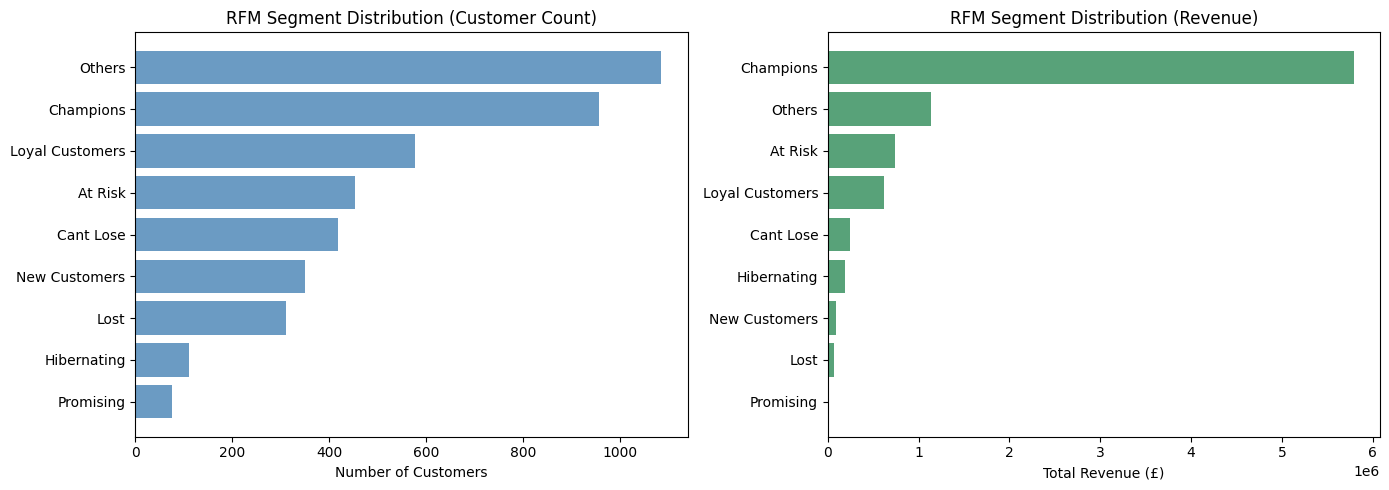

In [8]:
# Segment distribution (customer count)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_counts = rfm['Segment'].value_counts().sort_values(ascending=True)
axes[0].barh(seg_counts.index, seg_counts.values, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Number of Customers')
axes[0].set_title('RFM Segment Distribution (Customer Count)')

seg_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=True)
axes[1].barh(seg_revenue.index, seg_revenue.values, color='seagreen', alpha=0.8)
axes[1].set_xlabel('Total Revenue (£)')
axes[1].set_title('RFM Segment Distribution (Revenue)')
plt.tight_layout()
plt.show()

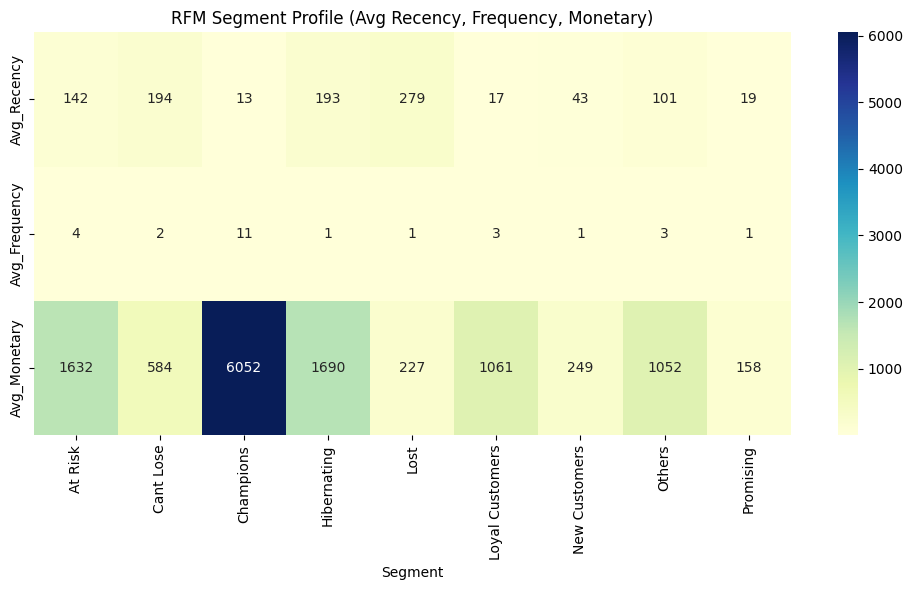

In [9]:
# Heatmap: Avg Recency vs Avg Frequency by Segment
heatmap_data = rfm.groupby('Segment').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(0)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_data.T, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax)
ax.set_title('RFM Segment Profile (Avg Recency, Frequency, Monetary)')
plt.tight_layout()
plt.show()

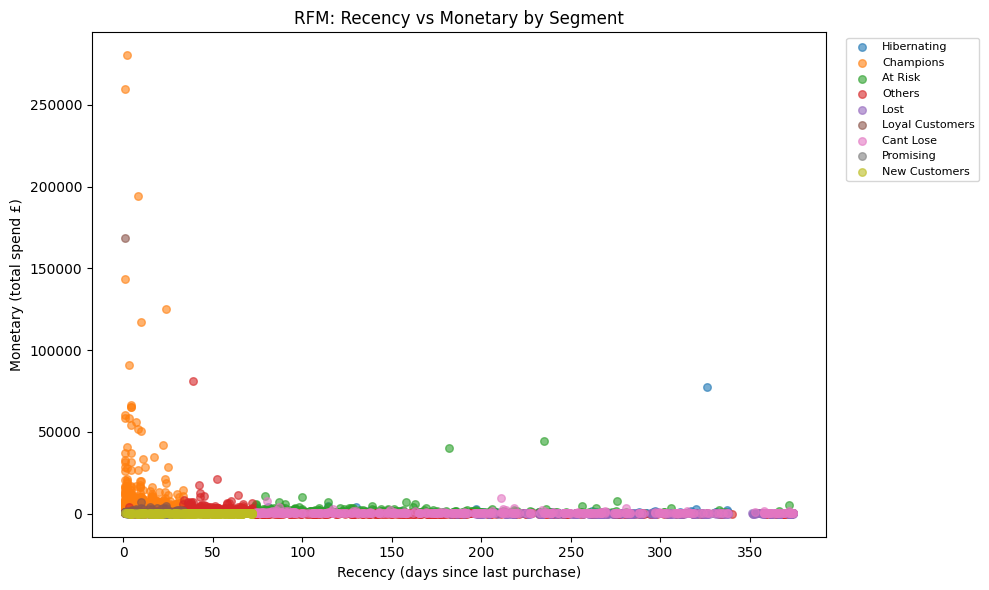

In [10]:
# Scatter: Recency vs Monetary, colored by Segment
fig, ax = plt.subplots(figsize=(10, 6))
for segment in rfm['Segment'].unique():
    subset = rfm[rfm['Segment'] == segment]
    ax.scatter(subset['Recency'], subset['Monetary'], label=segment, alpha=0.6, s=30)
ax.set_xlabel('Recency (days since last purchase)')
ax.set_ylabel('Monetary (total spend £)')
ax.set_title('RFM: Recency vs Monetary by Segment')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [11]:
# Top segments by customer count and revenue
print("Top 5 segments by customer count:")
print(rfm['Segment'].value_counts().head())
print("\nTop 5 segments by total revenue:")
print(rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False).head())

Top 5 segments by customer count:
Segment
Others             1085
Champions           957
Loyal Customers     578
At Risk             453
Cant Lose           418
Name: count, dtype: int64

Top 5 segments by total revenue:
Segment
Champions          5791640.740
Others             1141304.290
At Risk             739477.551
Loyal Customers     613465.601
Cant Lose           244145.542
Name: Monetary, dtype: float64
